   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 135MB/s]


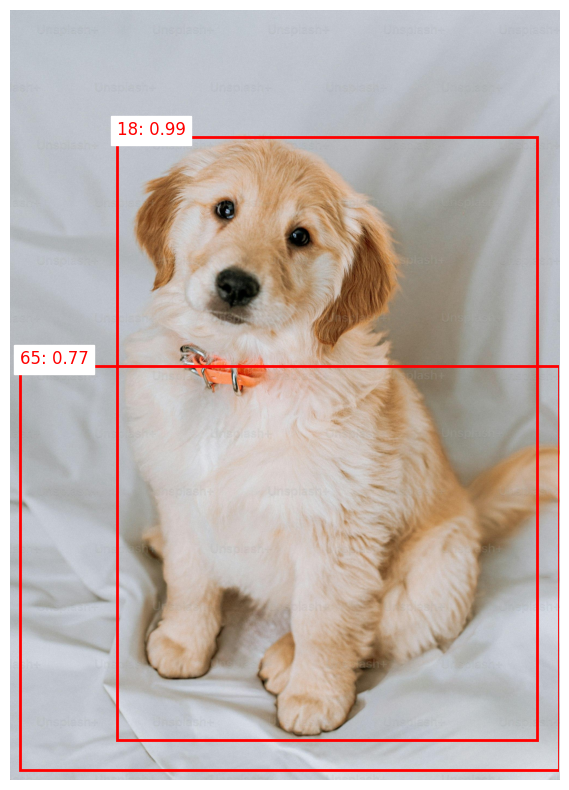

In [ ]:
# Step 1: Install required libraries (if not already installed)
!pip install torch torchvision opencv-python matplotlib requests

# Step 2: Import libraries
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import functional as F
import cv2
import matplotlib.pyplot as plt
import requests
from PIL import Image
import io

# Step 3: Load a pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Set the model to evaluation mode

# Step 4: Load and preprocess the image
def load_image(image_path):
    # Load image using OpenCV
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image from {image_path}. "
                       f"Please check if the file exists and is a valid image.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
    image = F.to_tensor(image)  # Convert to tensor
    return image

# Step 5: Perform object detection
def detect_objects(image_path, confidence_threshold=0.5):
    # Load the image
    image = load_image(image_path)

    # Add a batch dimension (required by the model)
    image = image.unsqueeze(0)

    # Perform inference
    with torch.no_grad():
        predictions = model(image)

    # Extract predictions
    boxes = predictions[0]['boxes']
    labels = predictions[0]['labels']
    scores = predictions[0]['scores']

    # Filter predictions based on confidence threshold
    keep = scores > confidence_threshold
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]

    return boxes, labels, scores

# Step 6: Visualize the results
def plot_detections(image_path, boxes, labels, scores):
    # Load the image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # Draw bounding boxes and labels
    for box, label, score in zip(boxes, labels, scores):
        box = box.cpu().numpy().astype(int)
        label = label.cpu().numpy()
        score = score.cpu().numpy()

        # Draw rectangle
        plt.gca().add_patch(plt.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            edgecolor='red', facecolor='none', linewidth=2
        ))

        # Add label and score
        plt.text(
            box[0], box[1] - 5, f'{label}: {score:.2f}',
            color='red', fontsize=12, backgroundcolor='white'
        )

    plt.axis('off')
    plt.show()

# Step 7: Run the detection on an example image
# Download an image from a URL using requests
url = "https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Open the image using PIL
    image = Image.open(io.BytesIO(response.content))
    image_path = r"C:\Users\arund\OneDrive\Desktop\dog.jpg"
    image.save(image_path)  # Save the image locally
else:
    raise ValueError(f"Failed to download image from {url}. Status code: {response.status_code}")

# Detect objects
boxes, labels, scores = detect_objects(image_path)

# Visualize the results
plot_detections(image_path, boxes, labels, scores)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 132MB/s]


Inference Time: 10.426 seconds


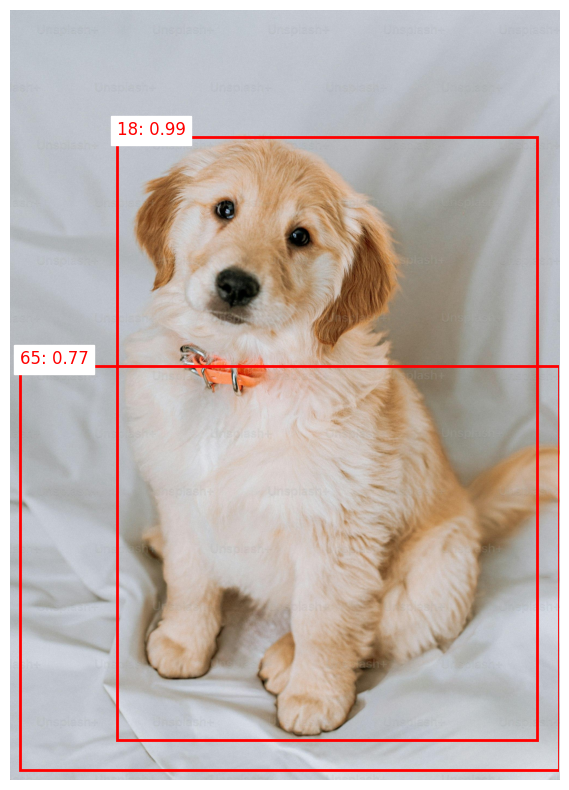

In [1]:
# Step 1: Install required libraries (if not already installed)
!pip install torch torchvision opencv-python matplotlib requests

# Step 2: Import libraries
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import functional as F
import cv2
import matplotlib.pyplot as plt
import requests
from PIL import Image
import io
import time  # Added for measuring inference time

# Step 3: Load a pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Set the model to evaluation mode

# Step 4: Load and preprocess the image
def load_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image from {image_path}.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = F.to_tensor(image)
    return image

# Step 5: Perform object detection with timing
def detect_objects(image_path, confidence_threshold=0.5):
    image = load_image(image_path)
    image = image.unsqueeze(0)

    # Measure inference time
    start_time = time.time()
    with torch.no_grad():
        predictions = model(image)
    end_time = time.time()
    inference_time = end_time - start_time
    print(f"Inference Time: {inference_time:.3f} seconds")

    boxes = predictions[0]['boxes']
    labels = predictions[0]['labels']
    scores = predictions[0]['scores']

    keep = scores > confidence_threshold
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]

    return boxes, labels, scores

# Step 6: Visualize the results
def plot_detections(image_path, boxes, labels, scores):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    for box, label, score in zip(boxes, labels, scores):
        box = box.cpu().numpy().astype(int)
        label = label.cpu().numpy()
        score = score.cpu().numpy()

        plt.gca().add_patch(plt.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            edgecolor='red', facecolor='none', linewidth=2
        ))

        plt.text(
            box[0], box[1] - 5, f'{label}: {score:.2f}',
            color='red', fontsize=12, backgroundcolor='white'
        )

    plt.axis('off')
    plt.show()

# Step 7: Run the detection on an example image
url = "https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
response = requests.get(url)

if response.status_code == 200:
    image = Image.open(io.BytesIO(response.content))
    image_path = r"C:\Users\arund\OneDrive\Desktop\dog.jpg"
    image.save(image_path)
else:
    raise ValueError(f"Failed to download image from {url}. Status code: {response.status_code}")

# Detect and visualize
boxes, labels, scores = detect_objects(image_path)
plot_detections(image_path, boxes, labels, scores)
